In [20]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option('display.max_columns', None)

In [21]:
#Load data and overview
#Change to path locally
steam = pd.read_csv("/Users/joannacalizo/Downloads/Uni/26.2/DATA301/Data301-GP/data/games_march2025_cleaned.csv")
print(steam.shape)


(89618, 47)


In [22]:
#Drop columns not useful for analysis
drop_cols = ['header_image', 'website', 'support_url', 'support_email',
             'metacritic_url', 'screenshots', 'movies', 'packages',
             'detailed_description', 'about_the_game', 'short_description',
             'notes']

steam_eda = steam.drop(columns=drop_cols)

In [23]:
#parse strings
def parse_py_list(x):
    if pd.isna(x):
        return []
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return []

steam_eda['genres_list'] = steam_eda['genres'].apply(parse_py_list)
steam_eda['categories_list'] = steam_eda['categories'].apply(parse_py_list)
steam_eda['developers_list'] = steam_eda['developers'].apply(parse_py_list)
steam_eda['publishers_list'] = steam_eda['publishers'].apply(parse_py_list)

steam_eda['n_genres'] = steam_eda['genres_list'].apply(len)
steam_eda['n_categories'] = steam_eda['categories_list'].apply(len)

# First/primary genre, useful for simple grouping
steam_eda['primary_genre'] = steam_eda['genres_list'].apply(lambda x: x[0] if len(x) > 0 else np.nan)

# estimated_owners: "100000000 - 200000000" -> numeric midpoint
owners_split = steam_eda['estimated_owners'].str.split(' - ', expand=True)
steam_eda['owners_low'] = pd.to_numeric(owners_split[0], errors='coerce')
steam_eda['owners_high'] = pd.to_numeric(owners_split[1], errors='coerce')
steam_eda['owners_mid'] = (steam_eda['owners_low'] + steam_eda['owners_high']) / 2

In [24]:
#Missing data
missing_summary = (
    steam_eda.isna().sum()
    .reset_index()
    .rename(columns={'index': 'column', 0: 'n_missing'})
)
missing_summary['pct_missing'] = round(missing_summary['n_missing'] / len(steam_eda) * 100, 2)
missing_summary = missing_summary[missing_summary['n_missing'] > 0].sort_values('n_missing', ascending=False)

missing_summary

,column,n_missing,pct_missing
20,score_rank,89579,99.96
6,reviews,79217,88.39
41,primary_genre,212,0.24


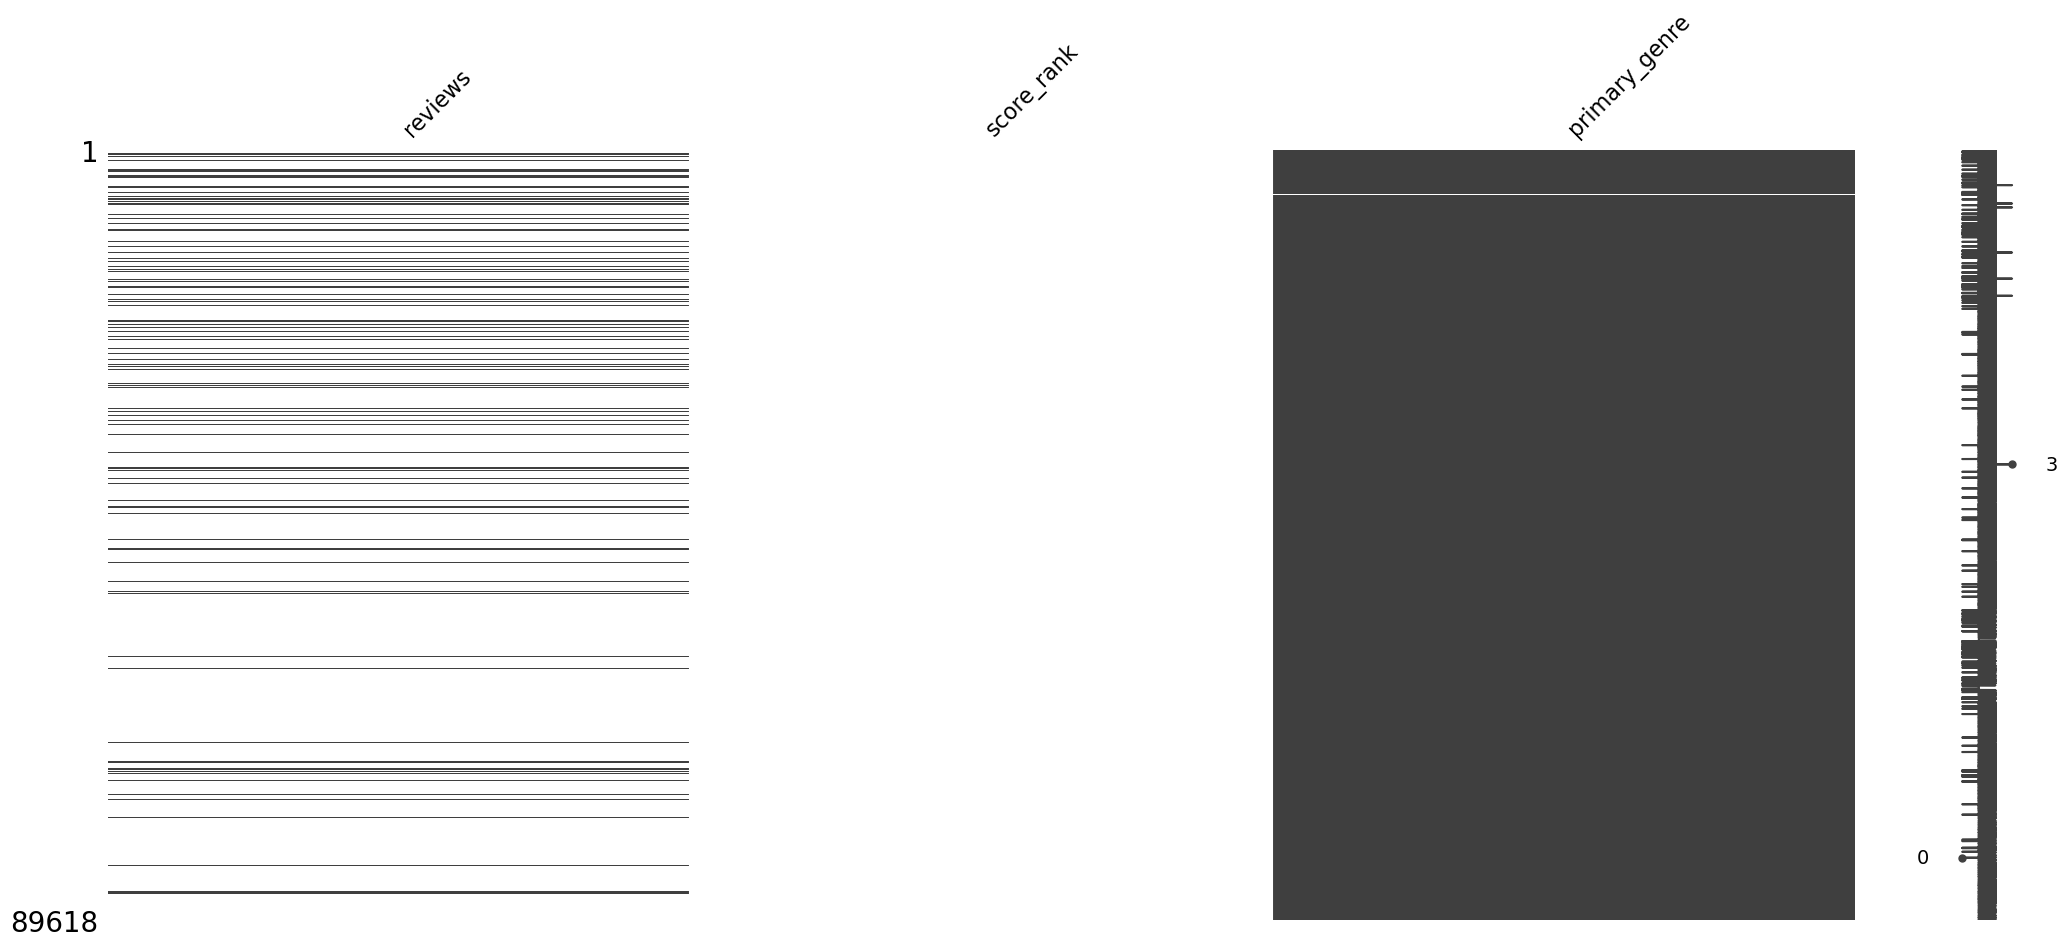

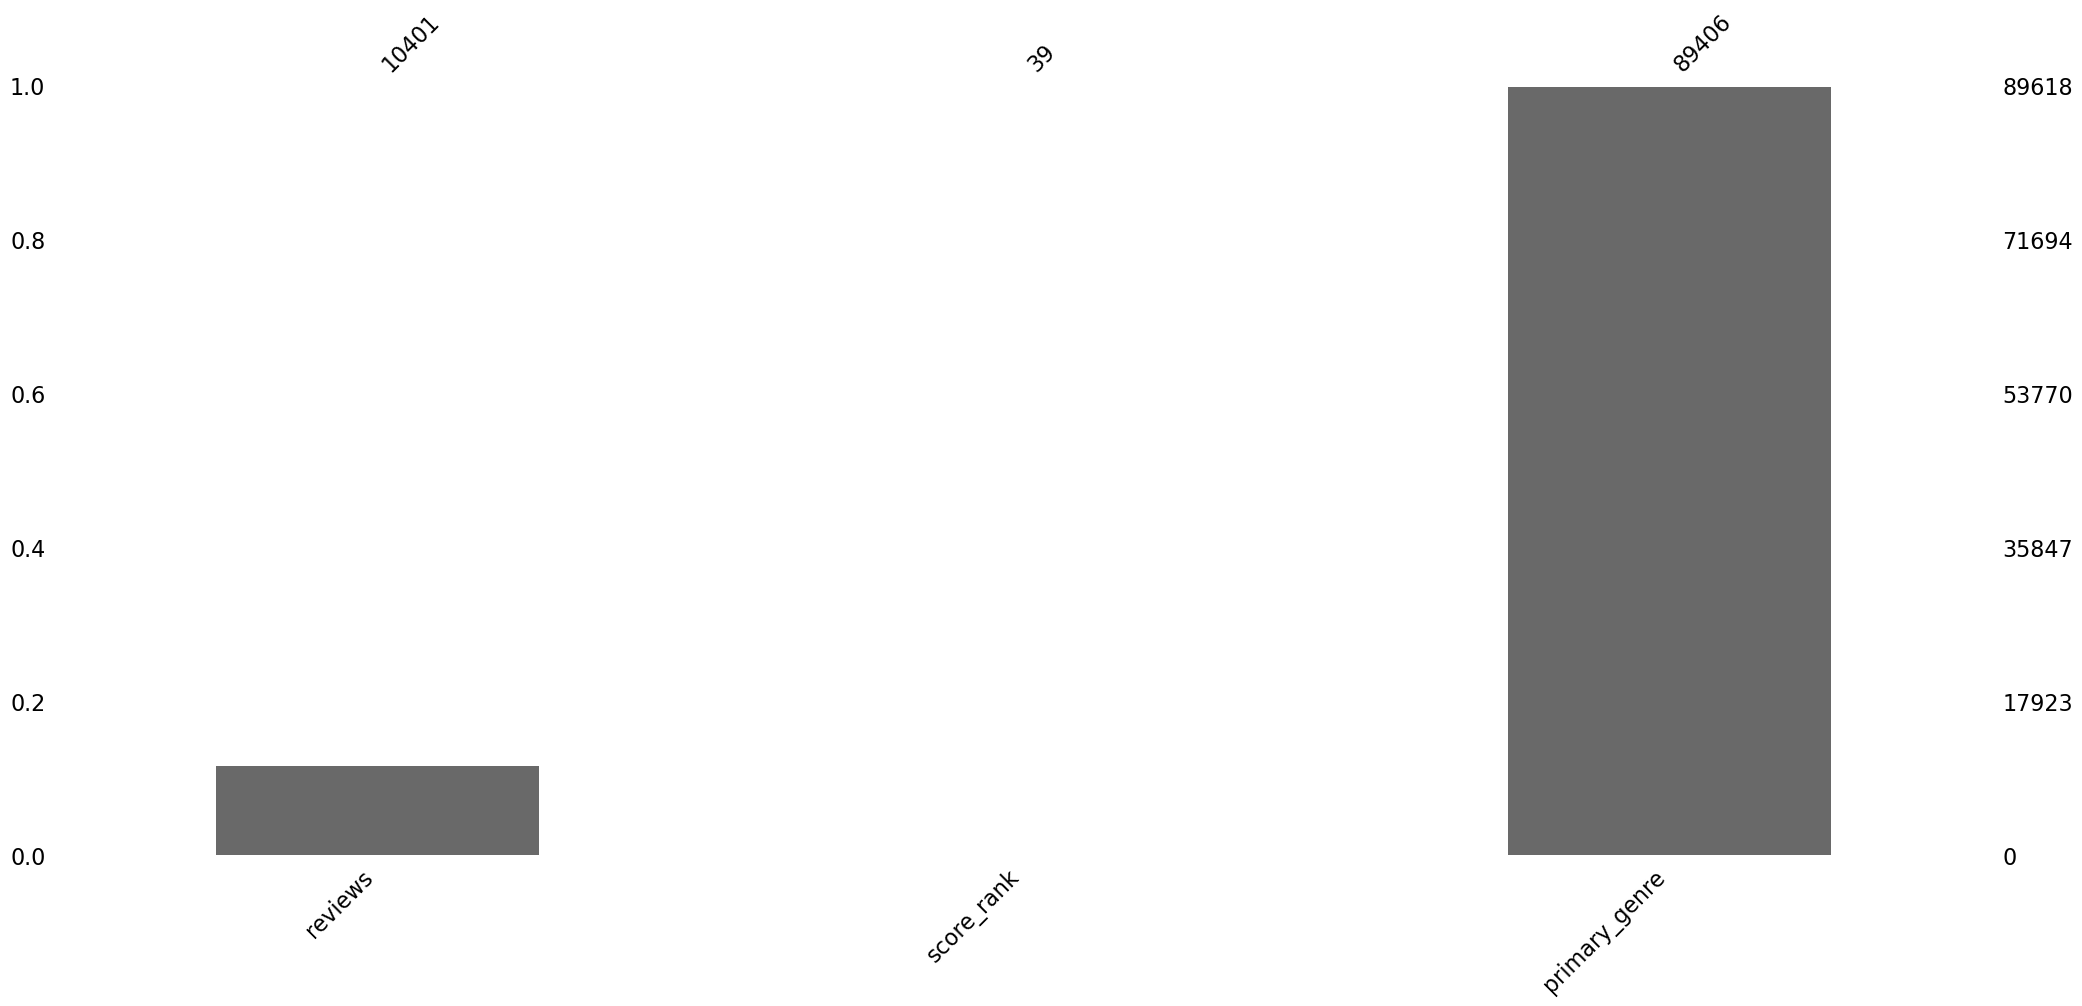

In [25]:
cols_with_na = steam_eda.columns[steam_eda.isna().any()].tolist()

msno.matrix(steam_eda[cols_with_na])
plt.show()

msno.bar(steam_eda[cols_with_na])
plt.show()

In [26]:
#Duplicate rows
dupe_mask = steam['appid'].duplicated(keep=False)
duplicates = steam[dupe_mask].sort_values('appid')

duplicates

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,header_image,website,support_url,support_email,windows,mac,linux,metacritic_score,metacritic_url,achievements,recommendations,notes,supported_languages,full_audio_languages,packages,developers,publishers,categories,genres,screenshots,movies,user_score,score_rank,positive,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent


Filtering

In [27]:
# Steam marks "fewer than 10 reviews" as num_reviews_total == -1 and pct_pos_total == -1
# (not NaN) - so these must be filtered out, not imputed
steam_eda['num_reviews_total'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
# At n=10, a single review swings pct_pos_total by ~10 points - too noisy
#MIN_REVIEWS = 30 cuts that swing to ~3 points per review while keeping a large sample
MIN_REVIEWS = 30

steam_reviewed = steam_eda[steam_eda['num_reviews_total'] >= MIN_REVIEWS].copy()
print(f"Games kept: {len(steam_reviewed)} / {len(steam_eda)} "
      f"({len(steam_reviewed)/len(steam_eda)*100:.1f}%)")

Games kept: 34583 / 89618 (38.6%)


Cleaning genres

In [28]:
#Drop games with no genre listed
n_zero_genre = (steam_reviewed['genres_list'].apply(len) == 0).sum()
print(f"zero genres in reviewed: {n_zero_genre}")

steam_reviewed_g = steam_reviewed[steam_reviewed['genres_list'].apply(len) > 0].copy()

zero genres in reviewed: 109


In [29]:
NON_GENRE_DESCRIPTORS = {"Violent", "Gore", "Nudity", "Sexual Content", "Free To Play", "Early Access"}

steam_genre = steam_reviewed_g.explode('genres_list').rename(columns={'genres_list': 'genre'})
steam_genre = steam_genre[steam_genre['genre'].notna() & (steam_genre['genre'] != '')]

n_before = steam_genre['genre'].nunique()
steam_genre = steam_genre[~steam_genre['genre'].isin(NON_GENRE_DESCRIPTORS)]
n_after = steam_genre['genre'].nunique()

print(f"before removing descriptors: {n_before}")
print(f"after removing descriptors:  {n_after}")

before removing descriptors: 27
after removing descriptors:  21


Distributions of success outcome variables (Average play time and Positive reviews)

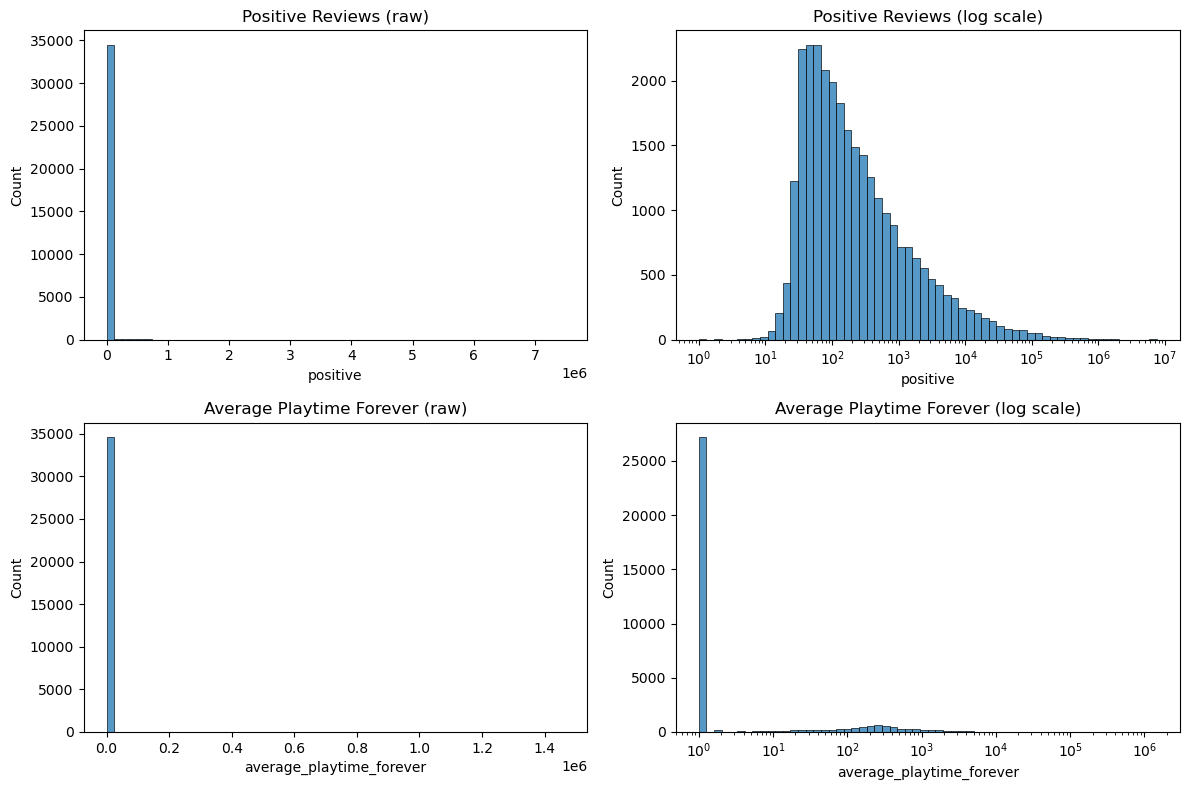

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(steam_reviewed['positive'], bins=60, ax=axes[0, 0])
axes[0, 0].set_title('Positive Reviews (raw)')

sns.histplot(steam_reviewed['positive'], bins=60, ax=axes[0, 1], log_scale=(True, False))
axes[0, 1].set_title('Positive Reviews (log scale)')

sns.histplot(steam_reviewed['average_playtime_forever'], bins=60, ax=axes[1, 0])
axes[1, 0].set_title('Average Playtime Forever (raw)')

sns.histplot(steam_reviewed['average_playtime_forever'] + 1, bins=60, ax=axes[1, 1], log_scale=(True, False))
axes[1, 1].set_title('Average Playtime Forever (log scale)')

plt.tight_layout()
plt.show()

In [31]:
steam_reviewed[['positive', 'negative', 'pct_pos_total', 'average_playtime_forever']].describe()

,positive,negative,pct_pos_total,average_playtime_forever
count,3.458300e+04,3.458300e+04,34583.000000,3.458300e+04
mean,3.239929e+03,5.361109e+02,78.201371,2.869032e+02
std,5.094164e+04,9.833350e+03,15.519655,1.095814e+04
min,0.000000e+00,0.000000e+00,1.000000,0.000000e+00
25%,3.600000e+01,6.000000e+00,70.000000,0.000000e+00
50%,1.010000e+02,2.600000e+01,82.000000,0.000000e+00
75%,4.330000e+02,1.030000e+02,90.000000,0.000000e+00
max,7.480813e+06,1.135108e+06,100.000000,1.462997e+06


Relationship between positive reviews and average play time

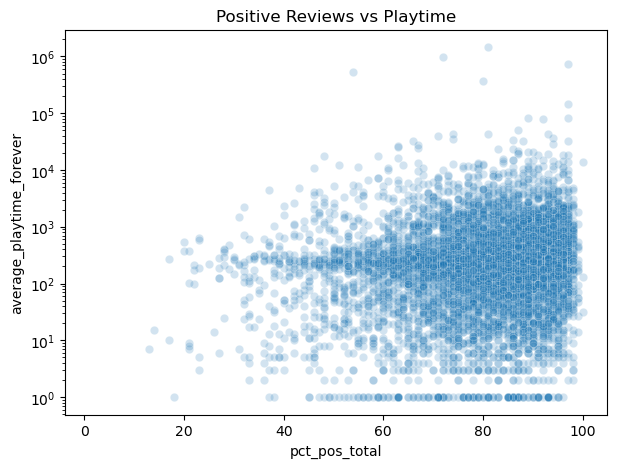

,pct_pos_total,average_playtime_forever,positive
pct_pos_total,1.000000,0.003935,0.036428
average_playtime_forever,0.003935,1.000000,0.031099
positive,0.036428,0.031099,1.000000


In [32]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=steam_reviewed, x='pct_pos_total', y='average_playtime_forever', alpha=0.2)
plt.yscale('log')
plt.title('Positive Reviews vs Playtime')
plt.show()

steam_reviewed[['pct_pos_total', 'average_playtime_forever', 'positive']].corr()

Filtering by play time

In [36]:
n_zero_playtime = (steam_reviewed['average_playtime_forever'] == 0).sum()
pct_zero_playtime = n_zero_playtime / len(steam_reviewed) * 100
print(f"Games with 0 average playtime: {n_zero_playtime} ({pct_zero_playtime:.1f}%)")

Games with 0 average playtime: 27160 (78.5%)
